In [1]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import os
import copy
import time
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## choose which GPU to use
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


## Configuration — fixed physiological parameters & input ranges

In [2]:
# Fixed physiological parameters (identical to PET_NN_LATEST.ipynb)
MET        = 1.7
CLO        = 0.45
AGE        = 35
SEX        = "male"
HEIGHT_M   = 1.7
WEIGHT_KG  = 65.0
P_ATM_HPA  = 1010.0
POSITION   = "sitting"
WME        = 0.0

# Variable input ranges
TDB_MIN, TDB_MAX = 10.0, 50.0
TR_MIN,  TR_MAX  = 10.0, 80.0
V_MIN,   V_MAX   = 0.0003, 10.0
RH_MIN,  RH_MAX  = 30.0, 100.0

N_TRAIN = 30_000
N_TEST  = 10_000

SEED = 2025


## Reference solver — `pythermalcomfort.pet_steady`

A thin wrapper that pins all fixed physiological parameters and is robust to both the v2 (numeric position/sex codes, float return) and v3 (string arguments, dataclass return) APIs of `pythermalcomfort`.

In [3]:
from pythermalcomfort.models import pet_steady

def pet_reference(tdb, tr, v, rh):
    """Ground-truth PET [degC] for a single condition, all physiological params fixed."""
    try:
        # newer pythermalcomfort API (string position/sex, dataclass return)
        res = pet_steady(tdb=tdb, tr=tr, v=v, rh=rh,
                         met=MET, clo=CLO,
                         p_atm=P_ATM_HPA, position=POSITION,
                         age=AGE, sex=SEX,
                         weight=WEIGHT_KG, height=HEIGHT_M, wme=WME)
    except (TypeError, ValueError):
        # older API expects integer codes: position 1 = sitting, sex 1 = male
        pos_code = 1 if POSITION == "sitting" else 2
        sex_code = 1 if SEX == "male" else 2
        res = pet_steady(tdb=tdb, tr=tr, v=v, rh=rh,
                         met=MET, clo=CLO,
                         p_atm=P_ATM_HPA, position=pos_code,
                         age=AGE, sex=sex_code,
                         weight=WEIGHT_KG, height=HEIGHT_M, wme=WME)
    return float(res.pet) if hasattr(res, "pet") else float(res)

# quick sanity check
pet_reference(30.0, 40.0, 1.0, 50.0)


32.09

## Data generation

Uniformly sample the 4 variable inputs within their ranges and label every sample with `pet_steady`. Train and test sets are generated from independent random draws.

In [4]:
rng = np.random.default_rng(SEED)

# Safe-zone boundary: at/below 30 C any RH is safe; above 30 C the max safe RH
# drops as tdb rises. v is unrestricted; tr is safe whenever (tdb, rh) is safe.
SAFE_TDB_BREAKPOINTS = [30.0, 34.0, 38.0, 42.0, 46.0, 50.0]
SAFE_RH_BREAKPOINTS  = [100.0, 80.0, 70.0, 50.0, 40.0, 40.0]

def safe_rh_max(tdb):
    return np.interp(tdb, SAFE_TDB_BREAKPOINTS, SAFE_RH_BREAKPOINTS)

def sample_inputs(n, rng):
    kept = []
    n_remaining = n
    while n_remaining > 0:
        batch = max(int(n_remaining / 0.75), 1000)   # ~81% of the box is safe
        tdb = rng.uniform(TDB_MIN, TDB_MAX, batch)
        tr  = rng.uniform(TR_MIN,  TR_MAX,  batch)
        v   = rng.uniform(V_MIN,   V_MAX,   batch)
        rh  = rng.uniform(RH_MIN,  RH_MAX,  batch)
        mask = rh <= safe_rh_max(tdb)
        kept.append(np.column_stack([tdb, tr, v, rh])[mask])
        n_remaining -= mask.sum()
    return np.vstack(kept)[:n]

def label_inputs(X):
    y = np.empty(len(X))
    t0 = time.perf_counter()
    for i, (tdb, tr, v, rh) in enumerate(X):
        y[i] = pet_reference(tdb, tr, v, rh)
        if (i + 1) % 5000 == 0:
            print(f"  {i+1}/{len(X)} labelled  ({time.perf_counter()-t0:.1f} s)")
    return y

X_train_raw = sample_inputs(N_TRAIN, rng)
X_test_raw  = sample_inputs(N_TEST,  rng)

print("Labelling training set:")
Y_train_raw = label_inputs(X_train_raw)
print("Labelling test set:")
Y_test_raw  = label_inputs(X_test_raw)


Labelling training set:


  5000/30000 labelled  (24.0 s)


  10000/30000 labelled  (43.6 s)


  15000/30000 labelled  (63.6 s)


  20000/30000 labelled  (80.4 s)


  25000/30000 labelled  (98.1 s)


  30000/30000 labelled  (118.1 s)
Labelling test set:


  5000/10000 labelled  (17.8 s)


  10000/10000 labelled  (33.5 s)


In [5]:
train_df = pd.DataFrame(X_train_raw, columns=["tdb", "tr", "v", "rh"])
train_df["pet"] = Y_train_raw
train_df


,tdb,tr,v,rh,pet
0,25.280390,37.991359,8.532046,86.816238,24.51
1,43.490211,30.150035,5.004008,43.856539,46.82
2,13.089001,44.885424,2.617766,71.302525,15.58
3,22.698256,71.802395,2.134733,90.379763,37.06
4,21.432997,47.607134,9.895399,33.858856,19.13
...,...,...,...,...,...
29995,15.980816,43.334473,0.353654,94.697844,27.46
29996,22.778890,31.276240,7.843035,70.430900,19.88
29997,21.470741,67.624352,6.421690,40.789836,24.69
29998,36.759033,26.420382,2.315198,65.736098,37.54


## Input data distribution

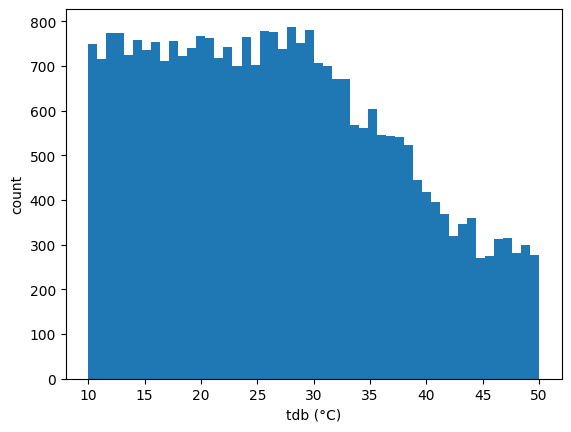

In [6]:
plt.hist(train_df['tdb'], bins=50);
plt.xlabel('tdb (°C)'); plt.ylabel('count');

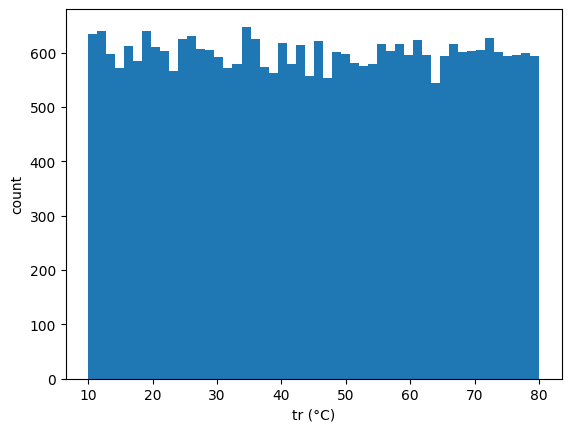

In [7]:
plt.hist(train_df['tr'], bins=50);
plt.xlabel('tr (°C)'); plt.ylabel('count');

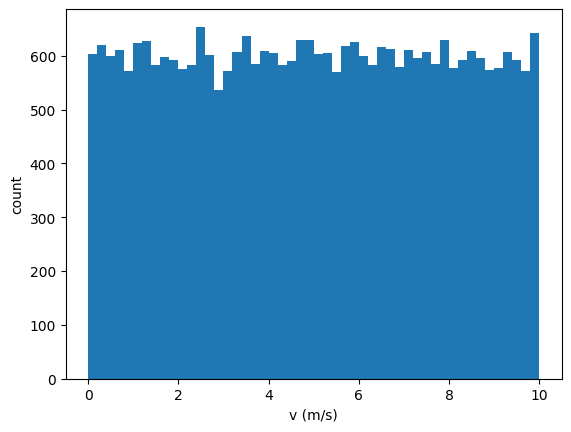

In [8]:
plt.hist(train_df['v'], bins=50);
plt.xlabel('v (m/s)'); plt.ylabel('count');

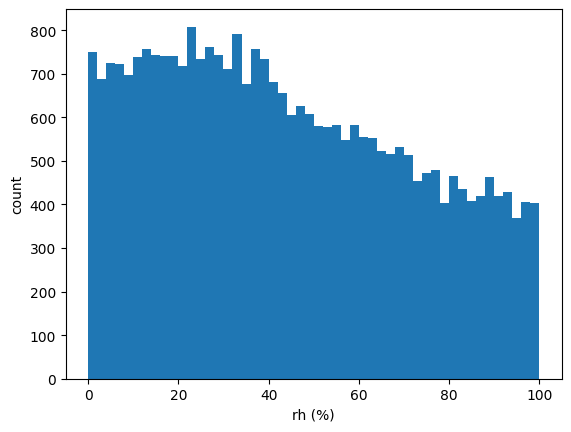

In [9]:
plt.hist(train_df['rh'], bins=50);
plt.xlabel('rh (%)'); plt.ylabel('count');

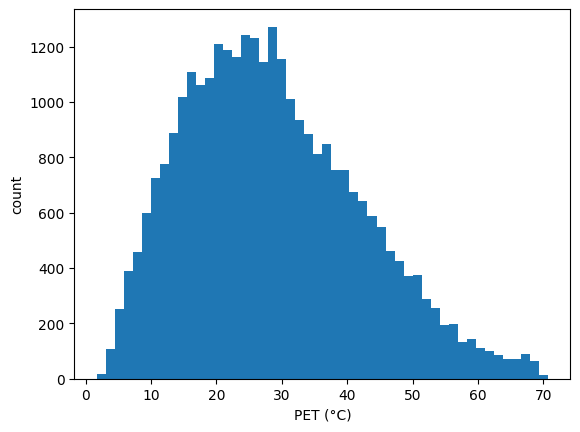

In [10]:
plt.hist(train_df['pet'], bins=50);
plt.xlabel('PET (°C)'); plt.ylabel('count');

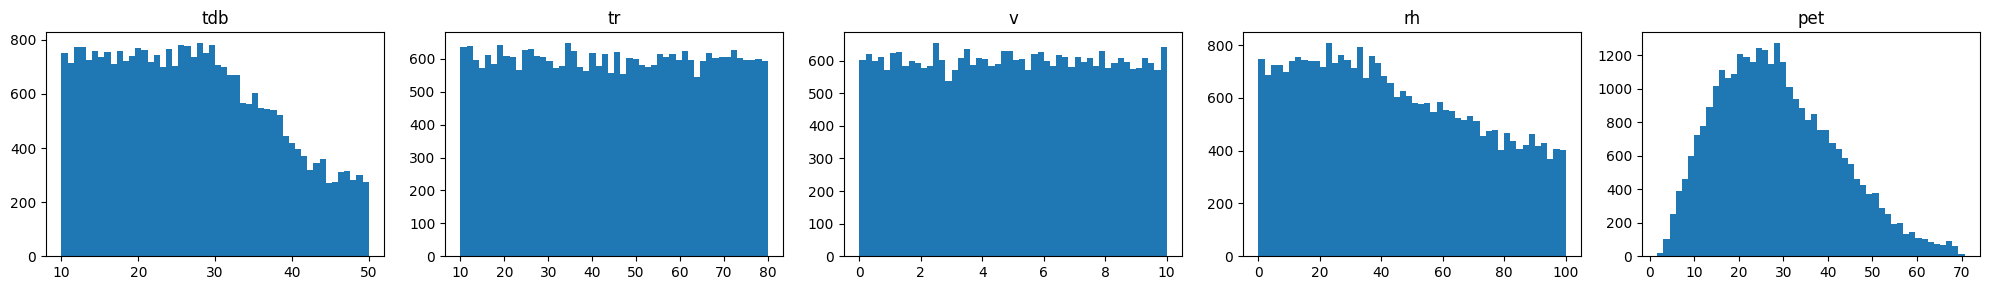

In [11]:
# combined view of all four inputs + label
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for ax, col in zip(axes, ["tdb", "tr", "v", "rh", "pet"]):
    ax.hist(train_df[col], bins=50)
    ax.set_title(col)
plt.tight_layout();

## Normalized data

    # data normalization
    tdb   -> tdb / 100
    tr    -> tr  / 100
    v     -> v   / 10
    rh    -> rh  / 100
    log_v -> (log(v) - log(V_MIN)) / (log(V_MAX) - log(V_MIN))   # engineered feature: v spans 4 orders of magnitude, this resolves the low-wind regime
    pet   -> pet / 100   (output scaling)

In [5]:
def scale_X(X_raw):
    X_raw = np.asarray(X_raw, dtype=np.float64)
    tdb, tr, v, rh = X_raw[:, 0], X_raw[:, 1], X_raw[:, 2], X_raw[:, 3]
    # log(v) engineered feature: v spans 4 orders of magnitude (0.0003-10) so a
    # linear scaling leaves almost no resolution in the low-wind regime.
    log_v = (np.log(v) - np.log(V_MIN)) / (np.log(V_MAX) - np.log(V_MIN))
    return np.column_stack([tdb / 100.0, tr / 100.0, v / 10.0, rh / 100.0, log_v])

def scale_Y(Y_raw):
    return (Y_raw / 100.0).reshape(-1, 1)   # pet / 100

def unscale_Y(Y_scaled):
    return np.asarray(Y_scaled).reshape(-1) * 100.0

X_train, Y_train = scale_X(X_train_raw), scale_Y(Y_train_raw)
X_test,  Y_test  = scale_X(X_test_raw),  scale_Y(Y_test_raw)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape


((30000, 5), (30000, 1), (10000, 5), (10000, 1))

## Model definition & training

Same two-branch MLP structure as the template, adapted to the 4 PET inputs: the temperature pair `(tdb, tr)` takes the place of the operating-condition branch and the air pair `(v, rh)` takes the place of the parameter branch. Activations are `SiLU` with standard He init, output head is a single PET value. Trained with Adam + a warmup-cosine-decay LR scheduler for the full 1200 epochs.

**Why not the SIREN-style `sin(2π·x)` activation used previously:** with that periodic activation, training converged to R² ≈ 0 (MAE ≈ 11°C) — essentially predicting the mean regardless of input. SIREN's periodic nonlinearity is built for high-frequency implicit signal fitting (images/audio); PET is a smooth, low-frequency function of 4 physical inputs, and stacking `sin(2π·x)` 4 layers deep made the loss landscape needlessly rugged. Swapping to `SiLU` + He init on the same two-branch structure fixed convergence. The training loop was also rewritten to move data to device once and run each epoch as a single `jax.lax.scan` call instead of ~400 individually-dispatched Python steps — the main lever for CPU training speed.

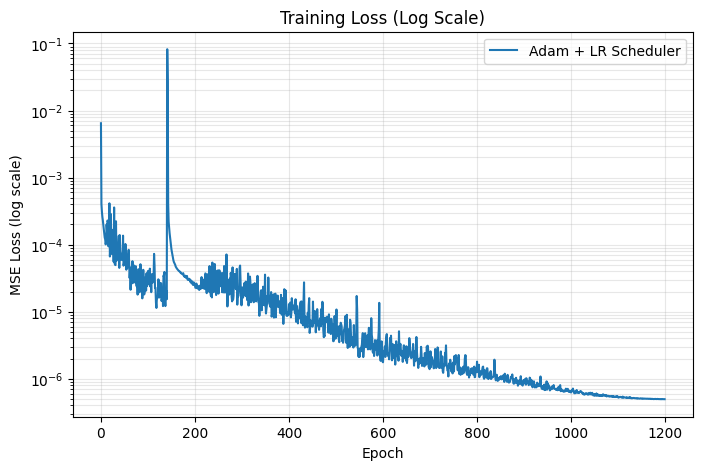

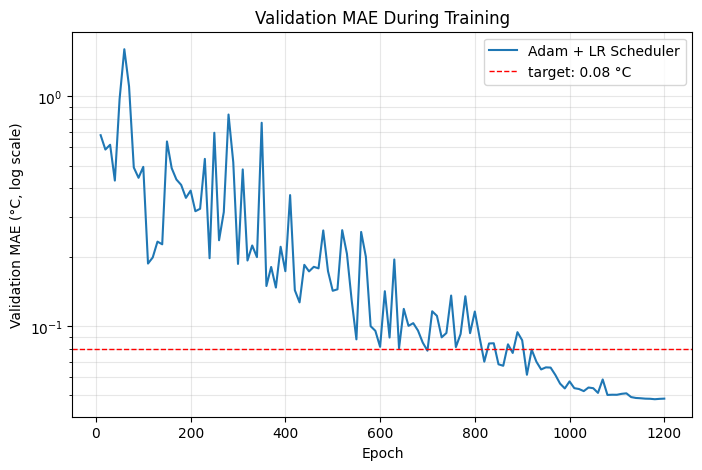

Adam + LR Scheduler: R2 PET = 0.999953498506812  | best val MAE (degC) = 0.048160965321858706


In [1]:
# --------------------------------
# Model definition: SiLU MLP with standard He init
# --------------------------------
class MLP(nn.Module):
    width: int = 256

    @nn.compact
    def __call__(self, inputs):
        init = nn.initializers.he_normal()
        act = nn.silu
        Tdb, Tr, V, Rh, LogV = jnp.split(inputs, [1, 2, 3, 4], axis=-1)

        Temps = jnp.hstack([Tdb, Tr])
        Temps = act(nn.Dense(128, kernel_init=init)(Temps))
        Temps = act(nn.Dense(self.width, kernel_init=init)(Temps))

        Air = jnp.hstack([V, Rh, LogV])
        Air = act(nn.Dense(self.width, kernel_init=init)(Air))
        Air = act(nn.Dense(self.width, kernel_init=init)(Air))

        merged = jnp.hstack([Temps, Air])
        merged = act(nn.Dense(self.width, kernel_init=init)(merged))
        merged = act(nn.Dense(self.width, kernel_init=init)(merged))

        return nn.Dense(1, kernel_init=init)(merged)

# --------------------------------
# Training function: X_tr/Y_tr/X_val/Y_val are moved to device once (not
# per-batch), and each epoch's batches run as a single jax.lax.scan call
# instead of a Python loop over ~steps-per-epoch individually-jitted calls --
# this was the main training-time bottleneck previously (500k+ dispatched
# steps for a 1200-epoch/batch-64 run). Also tracks held-out validation MAE
# in raw degC; patience=None runs the full requested epoch budget.
# --------------------------------
def make_batches(X, Y, idx, batch_size):
    n_batches = len(idx) // batch_size
    idx = idx[: n_batches * batch_size]
    Xb = X[idx].reshape(n_batches, batch_size, X.shape[-1])
    Yb = Y[idx].reshape(n_batches, batch_size, Y.shape[-1])
    return Xb, Yb

def train_model(optimizer, params_init, X_tr, Y_tr, X_val, Y_val,
                 epochs=1200, batch_size=512, eval_every=10, patience=None, seed=0):
    opt_state = optimizer.init(params_init)
    params = params_init

    @jax.jit
    def scan_epoch(params, opt_state, Xb, Yb):
        def step(carry, batch):
            params, opt_state = carry
            x, y = batch
            loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
            updates, opt_state = optimizer.update(grads, opt_state, params)
            params = optax.apply_updates(params, updates)
            return (params, opt_state), loss
        (params, opt_state), losses = jax.lax.scan(step, (params, opt_state), (Xb, Yb))
        return params, opt_state, losses.mean()

    @jax.jit
    def predict(params, x):
        return model.apply(params, x)

    X_tr_j, Y_tr_j = jnp.array(X_tr), jnp.array(Y_tr)
    X_val_j = jnp.array(X_val)
    val_true_degC = unscale_Y(Y_val)

    rng = np.random.default_rng(seed)
    loss_history = []
    mae_history = []   # list of (epoch, val_mae_degC)
    best_mae, best_epoch, best_params = np.inf, 0, params

    for epoch in range(epochs):
        idx = rng.permutation(len(X_tr_j))
        Xb, Yb = make_batches(X_tr_j, Y_tr_j, idx, batch_size)
        params, opt_state, epoch_loss = scan_epoch(params, opt_state, Xb, Yb)
        loss_history.append(float(epoch_loss))

        if (epoch + 1) % eval_every == 0 or epoch == epochs - 1:
            val_pred_degC = unscale_Y(predict(params, X_val_j))
            val_mae = float(np.mean(np.abs(val_pred_degC - val_true_degC)))
            mae_history.append((epoch + 1, val_mae))
            if val_mae < best_mae:
                best_mae, best_epoch, best_params = val_mae, epoch + 1, params
            if patience is not None and (epoch + 1) - best_epoch >= patience * eval_every:
                print(f"  early stop at epoch {epoch+1} (best val MAE {best_mae:.4f} @ epoch {best_epoch})")
                break
    return best_params, loss_history, mae_history, best_mae

# Loss function
def loss_fn(params, x, y):
    preds = model.apply(params, x)
    return jnp.mean((preds - y)**2)

# --------------------------------
# Held-out validation split (from the training set) for MAE tracking
# --------------------------------
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train, Y_train, test_size=0.1, random_state=SEED
)

# --------------------------------
# Initialize model and params
# --------------------------------
model = MLP(width=256)
key = jax.random.PRNGKey(0)
params_init = model.init(key, jnp.ones((1, 5)))

# --------------------------------
# Train Adam + LR Scheduler (full 1200 epochs, no early stopping)
# --------------------------------
batch_size = 512
epochs = 1200
steps_per_epoch = len(X_tr) // batch_size
max_iter = epochs * steps_per_epoch
lr_scheduler = optax.warmup_cosine_decay_schedule(
    init_value=1e-4, peak_value=1e-3,
    warmup_steps=int(max_iter*0.05), decay_steps=max_iter, end_value=1e-6
)
adam_sched_optimizer = optax.adam(learning_rate=lr_scheduler)
params_sched, loss_history_sched, mae_history_sched, best_mae_sched = train_model(
    adam_sched_optimizer, params_init, X_tr, Y_tr, X_val, Y_val,
    epochs=epochs, batch_size=batch_size, patience=None
)

# --------------------------------
# Training Loss Curve (Log Scale)
# --------------------------------
plt.figure(figsize=(8,5))
plt.plot(loss_history_sched, label="Adam + LR Scheduler")
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Training Loss (Log Scale)")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

# --------------------------------
# Validation MAE Curve
# --------------------------------
plt.figure(figsize=(8,5))
epochs_sched, mae_sched = zip(*mae_history_sched)
plt.plot(epochs_sched, mae_sched, label="Adam + LR Scheduler")
plt.axhline(0.08, color='r', linestyle='--', linewidth=1, label='target: 0.08 °C')
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("Validation MAE (°C, log scale)")
plt.title("Validation MAE During Training")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

# --------------------------------
# Evaluate
# --------------------------------
y_pred_sched = model.apply(params_sched, jnp.array(X_test))
r2_pet_sched = r2_score(Y_test[:,0], np.array(y_pred_sched)[:,0])

print("Adam + LR Scheduler: R2 PET =", r2_pet_sched, " | best val MAE (degC) =", best_mae_sched)

In [7]:
# train
y_pred_sched = model.apply(params_sched, jnp.array(X_train))
truth, predict = Y_train[:,0], np.array(y_pred_sched)[:,0]
rl2 = jnp.linalg.norm(truth - predict) / jnp.linalg.norm(truth)
rl2 *100


Array(0.23503692, dtype=float32)

In [8]:
# test
y_pred_sched = model.apply(params_sched, jnp.array(X_test))
truth, predict = Y_test[:,0], np.array(y_pred_sched)[:,0]
rl2 = jnp.linalg.norm(truth - predict) / jnp.linalg.norm(truth)
rl2 *100


Array(0.2868933, dtype=float32)

In [9]:
# store weight to model folder
os.makedirs('model', exist_ok=True)

path = 'model/model_pet_solver.pickle'
with open(path, 'wb') as file:
    pickle.dump(params_sched, file)

path = 'model/model_pet_solver.pickle'
with open(path, 'rb') as file:
    params = pickle.load(file)


## Querying the surrogate

In [10]:
def pet_nn(tdb, tr, v, rh, params=None):
    """PET [degC] from the NN surrogate for scalar or array inputs."""
    if params is None:
        params = params_sched
    tdb, tr, v, rh = np.atleast_1d(tdb), np.atleast_1d(tr), np.atleast_1d(v), np.atleast_1d(rh)
    X_query = scale_X(np.column_stack([tdb, tr, v, rh]))
    Y_query = model.apply(params, jnp.array(X_query))
    pet = unscale_Y(Y_query)
    return pet[0] if pet.size == 1 else pet

# user input (environmental condition)
tdb, tr, v, rh = 30.0, 40.0, 1.0, 50.0
print("NN PET       :", pet_nn(tdb, tr, v, rh))
print("Reference PET:", pet_reference(tdb, tr, v, rh))


NN PET       : 32.11705
Reference PET: 32.09


## Benchmark vs `pythermalcomfort.pet_steady`

Accuracy (MAE / RMSE / relative error) and runtime on the full 10,000-sample test set.

In [11]:
# ---- accuracy on test set --------------------------------------
pet_true = Y_test_raw                                   # ground truth [degC]
pet_pred = pet_nn(X_test_raw[:,0], X_test_raw[:,1],
                  X_test_raw[:,2], X_test_raw[:,3], params=params)

err     = pet_pred - pet_true
mae     = np.mean(np.abs(err))
rmse    = np.sqrt(np.mean(err**2))
max_ae  = np.max(np.abs(err))
# relative L2 error (%) — consistent with the training-notebook metric
rel_l2  = np.linalg.norm(err) / np.linalg.norm(pet_true) * 100
# mean absolute relative error (%), guarded against near-zero PET
denom   = np.maximum(np.abs(pet_true), 1.0)
mape    = np.mean(np.abs(err) / denom) * 100

# ---- runtime: NN surrogate (batched, jitted) --------------------
X_test_scaled = jnp.array(scale_X(X_test_raw))
apply_jit = jax.jit(lambda p, x: model.apply(p, x))
_ = apply_jit(params, X_test_scaled).block_until_ready()   # warm-up / compile

n_rep = 20
t0 = time.perf_counter()
for _ in range(n_rep):
    _ = apply_jit(params, X_test_scaled).block_until_ready()
t_nn = (time.perf_counter() - t0) / n_rep

# ---- runtime: pythermalcomfort reference ------------------------
t0 = time.perf_counter()
for tdb, tr, v, rh in X_test_raw:
    pet_reference(tdb, tr, v, rh)
t_ref = time.perf_counter() - t0


In [12]:
# ---- benchmark summary ------------------------------------------
summary = pd.DataFrame({
    "Metric": ["MAE (°C)", "RMSE (°C)", "Max abs error (°C)",
               "Relative L2 error (%)", "Mean abs relative error (%)",
               "NN runtime, 10k samples (s)", "pet_steady runtime, 10k samples (s)",
               "Speed-up (×)"],
    "Value": [mae, rmse, max_ae, rel_l2, mape, t_nn, t_ref, t_ref / t_nn]
})
summary["Value"] = summary["Value"].map(lambda x: f"{x:.6g}")
summary


,Metric,Value
0,MAE (°C),0.0484412
1,RMSE (°C),0.0892542
2,Max abs error (°C),4.72158
3,Relative L2 error (%),0.286893
4,Mean abs relative error (%),0.161809
5,"NN runtime, 10k samples (s)",0.0931464
6,"pet_steady runtime, 10k samples (s)",63.7463
7,Speed-up (×),684.366


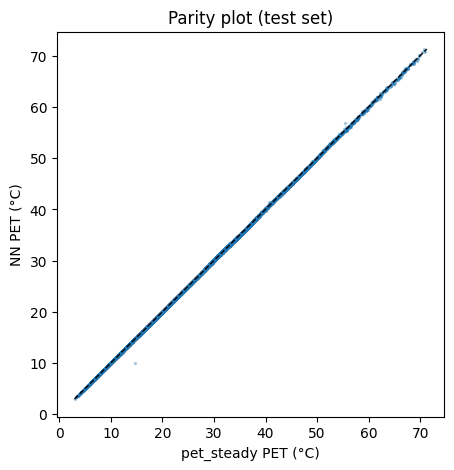

In [13]:
# parity plot: NN vs pet_steady
plt.figure(figsize=(5, 5))
plt.scatter(pet_true, pet_pred, s=2, alpha=0.3)
lims = [min(pet_true.min(), pet_pred.min()), max(pet_true.max(), pet_pred.max())]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('pet_steady PET (°C)'); plt.ylabel('NN PET (°C)')
plt.title('Parity plot (test set)');


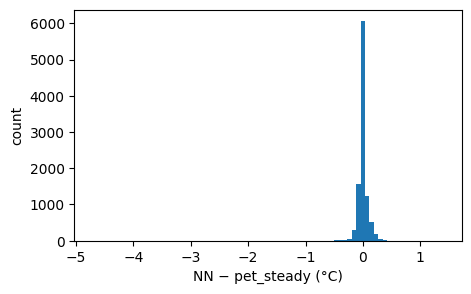

In [14]:
# error distribution
plt.figure(figsize=(5, 3))
plt.hist(err, bins=80)
plt.xlabel('NN − pet_steady (°C)'); plt.ylabel('count');


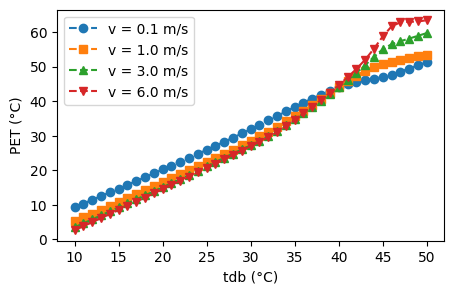

In [15]:
# sample output: PET vs tdb sweeps at several wind speeds (tr = tdb, rh = 50 %)
tdbs = np.arange(10, 51)
outputs = []
for v in [0.1, 1.0, 3.0, 6.0]:
    for tdb in tdbs:
        pet = pet_nn(float(tdb), float(tdb), v, 50.0)
        outputs.append([v, tdb, pet])
outputs = np.array(outputs)

plt.figure(figsize=(5, 3))
ix = (outputs[:,0] == 0.1); plt.plot(outputs[ix,1], outputs[ix,2], label='v = 0.1 m/s', marker='o', linestyle='--');
ix = (outputs[:,0] == 1.0); plt.plot(outputs[ix,1], outputs[ix,2], label='v = 1.0 m/s', marker='s', linestyle='--');
ix = (outputs[:,0] == 3.0); plt.plot(outputs[ix,1], outputs[ix,2], label='v = 3.0 m/s', marker='^', linestyle='--');
ix = (outputs[:,0] == 6.0); plt.plot(outputs[ix,1], outputs[ix,2], label='v = 6.0 m/s', marker='v', linestyle='--');
plt.xlabel('tdb (°C)'); plt.ylabel('PET (°C)'); plt.legend();


## Boundary-case analysis: runtime warnings across three sampling strategies

Uses the same ranges as **Section 2** (`TDB_MIN`..`RH_MAX`) to generate three independent 30,000-sample datasets: (1) plain uniform sampling (no restriction), (2) uniform sampling with the `tdb`/`rh` safe-zone restriction used in the data-generation section, and (3) uniform sampling that **resamples all 4 inputs whenever `pet_steady` raises a `RuntimeWarning`** (solver non-convergence) until a warning-free draw is found. No model training here, just data generation and visualization.

In [5]:
import warnings

N_BOUNDARY_CHECK = 30_000
rng_boundary = np.random.default_rng(SEED)

def sample_uniform_unrestricted(n, rng):
    """Plain uniform sampling over Section 2's ranges, no safe-zone restriction."""
    tdb = rng.uniform(TDB_MIN, TDB_MAX, n)
    tr  = rng.uniform(TR_MIN,  TR_MAX,  n)
    v   = rng.uniform(V_MIN,   V_MAX,   n)
    rh  = rng.uniform(RH_MIN,  RH_MAX,  n)
    return np.column_stack([tdb, tr, v, rh])

def label_and_flag_warnings(X):
    """Label every row with pet_reference, flagging rows where fsolve raised a RuntimeWarning."""
    pet = np.empty(len(X))
    warned = np.zeros(len(X), dtype=bool)
    t0 = time.perf_counter()
    for i, (tdb, tr, v, rh) in enumerate(X):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            pet[i] = pet_reference(tdb, tr, v, rh)
            warned[i] = any(issubclass(w.category, RuntimeWarning) for w in caught)
    print(f"  labelled {len(X)} in {time.perf_counter()-t0:.1f}s")
    return pet, warned

def sample_resample_on_warning(n, rng):
    """Uniform sampling over Section 2's ranges; whenever pet_reference raises a
    RuntimeWarning, discard that draw and redraw all 4 inputs until it doesn't."""
    X = np.empty((n, 4))
    pet = np.empty(n)
    n_draws = 0
    t0 = time.perf_counter()
    for i in range(n):
        while True:
            tdb = rng.uniform(TDB_MIN, TDB_MAX)
            tr  = rng.uniform(TR_MIN,  TR_MAX)
            v   = rng.uniform(V_MIN,   V_MAX)
            rh  = rng.uniform(RH_MIN,  RH_MAX)
            n_draws += 1
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always")
                val = pet_reference(tdb, tr, v, rh)
                warned = any(issubclass(w.category, RuntimeWarning) for w in caught)
            if not warned:
                break
        X[i] = [tdb, tr, v, rh]
        pet[i] = val
        if (i + 1) % 5000 == 0:
            print(f"  {i+1}/{n} labelled  ({time.perf_counter()-t0:.1f} s, {n_draws} draws so far)")
    print(f"  labelled {n} in {time.perf_counter()-t0:.1f}s  ({n_draws} total draws, {n_draws-n} resampled away)")
    return X, pet, n_draws

# --- no boundary restriction (plain uniform sampling over Section 2's ranges) ---
print("Generating + labelling: no boundary restriction")
X_nobound = sample_uniform_unrestricted(N_BOUNDARY_CHECK, rng_boundary)
pet_nobound, warned_nobound = label_and_flag_warnings(X_nobound)

# --- with the tdb/rh safe-zone restriction (sample_inputs from the data-generation section) ---
print("Generating + labelling: with safe-zone restriction")
X_safe = sample_inputs(N_BOUNDARY_CHECK, rng_boundary)
pet_safe, warned_safe = label_and_flag_warnings(X_safe)

# --- resample-on-warning (uniform draw, redraw whenever pet_steady warns) ---
print("Generating + labelling: resample-on-RuntimeWarning")
X_resample, pet_resample, n_draws_resample = sample_resample_on_warning(N_BOUNDARY_CHECK, rng_boundary)
warned_resample = np.zeros(N_BOUNDARY_CHECK, dtype=bool)   # by construction, none warn

print(f"No boundary restriction:    {warned_nobound.sum()} / {len(X_nobound)} samples raised a RuntimeWarning ({warned_nobound.mean()*100:.2f}%)")
print(f"With safe-zone restriction: {warned_safe.sum()} / {len(X_safe)} samples raised a RuntimeWarning ({warned_safe.mean()*100:.2f}%)")
print(f"Resample-on-warning:        {warned_resample.sum()} / {len(X_resample)} samples raised a RuntimeWarning (0.00%)  [{n_draws_resample} total draws, {n_draws_resample - N_BOUNDARY_CHECK} rejected/resampled]")

Generating + labelling: no boundary restriction


  labelled 30000 in 113.9s
Generating + labelling: with safe-zone restriction


  labelled 30000 in 101.6s
Generating + labelling: resample-on-RuntimeWarning


  5000/30000 labelled  (19.1 s, 5246 draws so far)


  10000/30000 labelled  (37.9 s, 10500 draws so far)


  15000/30000 labelled  (57.0 s, 15781 draws so far)


  20000/30000 labelled  (75.9 s, 21019 draws so far)


  25000/30000 labelled  (94.9 s, 26268 draws so far)


  30000/30000 labelled  (115.6 s, 31522 draws so far)
  labelled 30000 in 115.6s  (31522 total draws, 1522 resampled away)
No boundary restriction:    1463 / 30000 samples raised a RuntimeWarning (4.88%)
With safe-zone restriction: 0 / 30000 samples raised a RuntimeWarning (0.00%)
Resample-on-warning:        0 / 30000 samples raised a RuntimeWarning (0.00%)  [31522 total draws, 1522 rejected/resampled]


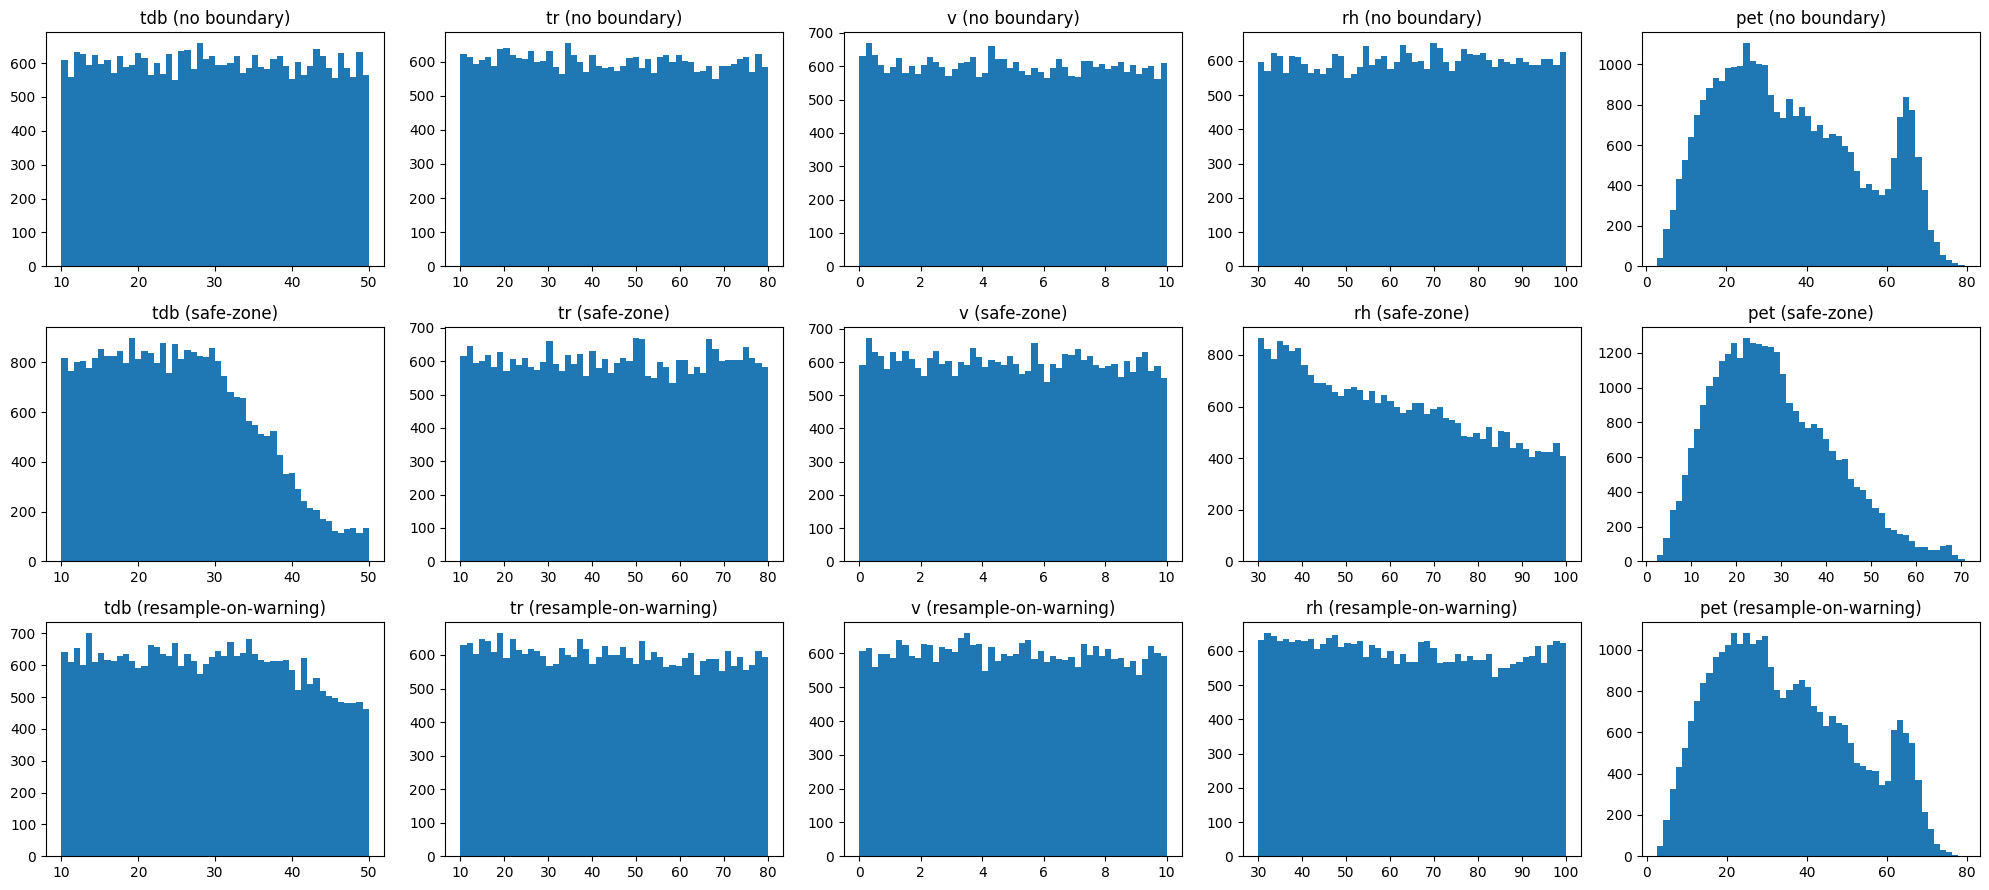

In [6]:
nobound_df = pd.DataFrame(X_nobound, columns=["tdb", "tr", "v", "rh"])
nobound_df["pet"] = pet_nobound
nobound_df["warned"] = warned_nobound

safe_df = pd.DataFrame(X_safe, columns=["tdb", "tr", "v", "rh"])
safe_df["pet"] = pet_safe
safe_df["warned"] = warned_safe

resample_df = pd.DataFrame(X_resample, columns=["tdb", "tr", "v", "rh"])
resample_df["pet"] = pet_resample
resample_df["warned"] = warned_resample

fig, axes = plt.subplots(3, 5, figsize=(20, 9))
for ax, col in zip(axes[0], ["tdb", "tr", "v", "rh", "pet"]):
    ax.hist(nobound_df[col], bins=50)
    ax.set_title(f"{col} (no boundary)")
for ax, col in zip(axes[1], ["tdb", "tr", "v", "rh", "pet"]):
    ax.hist(safe_df[col], bins=50)
    ax.set_title(f"{col} (safe-zone)")
for ax, col in zip(axes[2], ["tdb", "tr", "v", "rh", "pet"]):
    ax.hist(resample_df[col], bins=50)
    ax.set_title(f"{col} (resample-on-warning)")
plt.tight_layout()
plt.show()

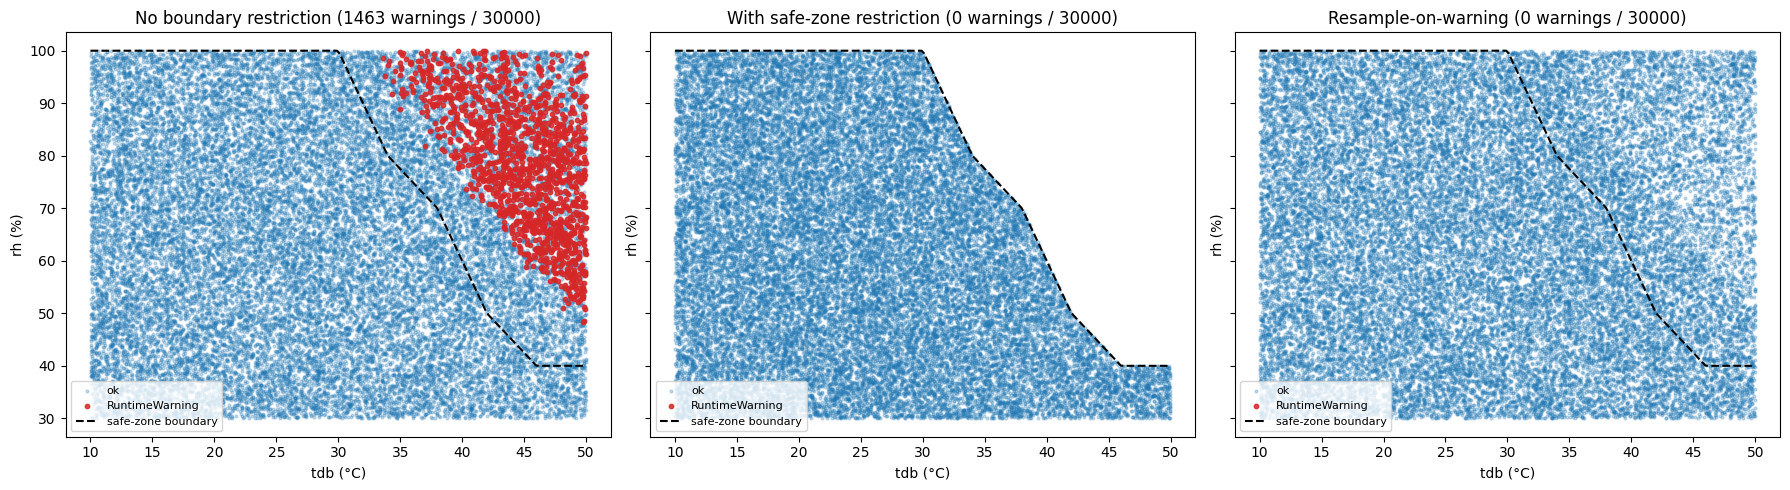

In [7]:
# data representation: which (tdb, rh) combinations trigger a RuntimeWarning
tdb_line = np.linspace(TDB_MIN, TDB_MAX, 200)
rh_line  = safe_rh_max(tdb_line)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

ax = axes[0]
ax.scatter(nobound_df.loc[~nobound_df.warned, "tdb"], nobound_df.loc[~nobound_df.warned, "rh"],
           s=4, alpha=0.25, color="tab:blue", label="ok")
ax.scatter(nobound_df.loc[nobound_df.warned, "tdb"], nobound_df.loc[nobound_df.warned, "rh"],
           s=10, alpha=0.85, color="tab:red", label="RuntimeWarning")
ax.plot(tdb_line, rh_line, "k--", lw=1.5, label="safe-zone boundary")
ax.set_title(f"No boundary restriction ({int(warned_nobound.sum())} warnings / {len(X_nobound)})")
ax.set_xlabel("tdb (°C)"); ax.set_ylabel("rh (%)"); ax.legend(loc="lower left", fontsize=8)

ax = axes[1]
ax.scatter(safe_df.loc[~safe_df.warned, "tdb"], safe_df.loc[~safe_df.warned, "rh"],
           s=4, alpha=0.25, color="tab:blue", label="ok")
ax.scatter(safe_df.loc[safe_df.warned, "tdb"], safe_df.loc[safe_df.warned, "rh"],
           s=10, alpha=0.85, color="tab:red", label="RuntimeWarning")
ax.plot(tdb_line, rh_line, "k--", lw=1.5, label="safe-zone boundary")
ax.set_title(f"With safe-zone restriction ({int(warned_safe.sum())} warnings / {len(X_safe)})")
ax.set_xlabel("tdb (°C)"); ax.set_ylabel("rh (%)"); ax.legend(loc="lower left", fontsize=8)

ax = axes[2]
ax.scatter(resample_df.loc[~resample_df.warned, "tdb"], resample_df.loc[~resample_df.warned, "rh"],
           s=4, alpha=0.25, color="tab:blue", label="ok")
ax.scatter(resample_df.loc[resample_df.warned, "tdb"], resample_df.loc[resample_df.warned, "rh"],
           s=10, alpha=0.85, color="tab:red", label="RuntimeWarning")
ax.plot(tdb_line, rh_line, "k--", lw=1.5, label="safe-zone boundary")
ax.set_title(f"Resample-on-warning ({int(warned_resample.sum())} warnings / {len(X_resample)})")
ax.set_xlabel("tdb (°C)"); ax.set_ylabel("rh (%)"); ax.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

linear frontier: rh = -2.921*tdb + 192.73  (10/1463 warnings fall below it)


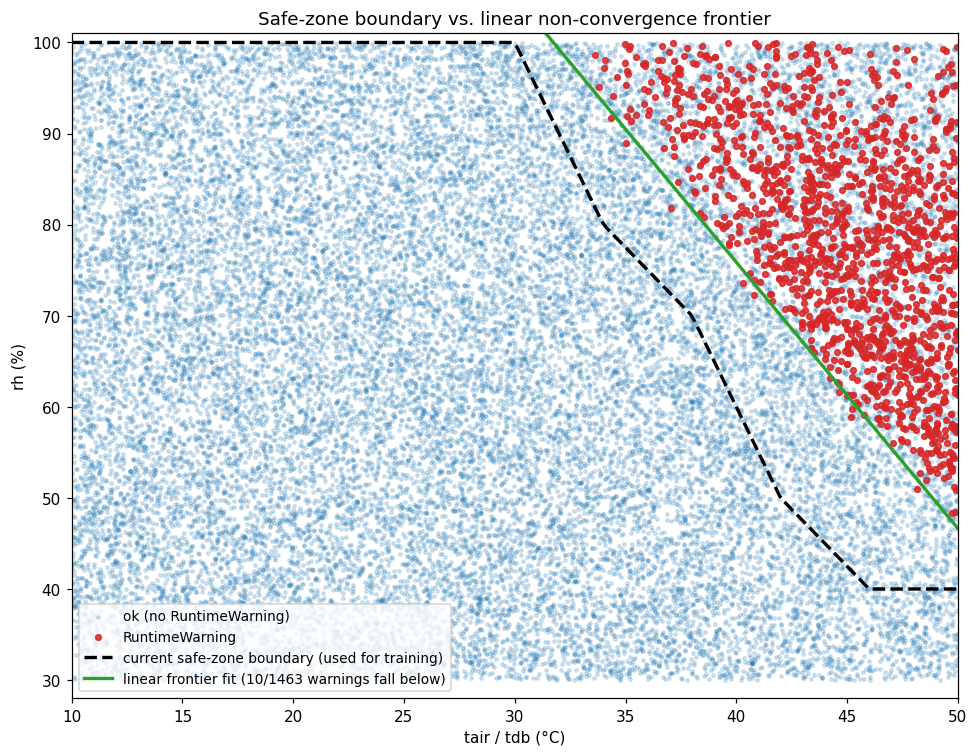

In [1]:
# how far can the tdb/rh safe-zone boundary be pushed? fit a single straight
# diagonal line through the empirical non-convergence frontier (lowest rh that
# raised a RuntimeWarning per tdb bin, across all sampled tr, v, from the
# unrestricted draw above) rather than following it bin-by-bin -- a few
# warning points are allowed to fall below the fitted line.
tdb_bins = np.linspace(TDB_MIN, TDB_MAX, 41)
bin_idx = np.digitize(nobound_df["tdb"], tdb_bins) - 1
bin_centers = (tdb_bins[:-1] + tdb_bins[1:]) / 2

frontier_rh = np.full(len(bin_centers), np.nan)
for b in range(len(bin_centers)):
    mask = bin_idx == b
    warned_rh = nobound_df.loc[mask & nobound_df["warned"], "rh"]
    if len(warned_rh) > 0:
        frontier_rh[b] = warned_rh.min()

valid = ~np.isnan(frontier_rh)
slope, intercept = np.polyfit(bin_centers[valid], frontier_rh[valid], 1)
frontier_line_rh = slope * tdb_line + intercept

n_below = (nobound_df.loc[nobound_df.warned, "rh"] <
           (slope * nobound_df.loc[nobound_df.warned, "tdb"] + intercept)).sum()
n_warned = int(nobound_df["warned"].sum())
print(f"linear frontier: rh = {slope:.3f}*tdb + {intercept:.2f}  "
      f"({n_below}/{n_warned} warnings fall below it)")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(nobound_df.loc[~nobound_df.warned, "tdb"], nobound_df.loc[~nobound_df.warned, "rh"],
           s=5, alpha=0.18, color="tab:blue", label="ok (no RuntimeWarning)")
ax.scatter(nobound_df.loc[nobound_df.warned, "tdb"], nobound_df.loc[nobound_df.warned, "rh"],
           s=14, alpha=0.85, color="tab:red", label="RuntimeWarning")
ax.plot(tdb_line, rh_line, "k--", lw=2.2, label="current safe-zone boundary (used for training)")
ax.plot(tdb_line, frontier_line_rh, color="tab:green", lw=2.2,
        label=f"linear frontier fit ({n_below}/{n_warned} warnings fall below)")
ax.set_xlim(TDB_MIN, TDB_MAX)
ax.set_ylim(nobound_df["rh"].min() - 2, 101)
ax.set_xlabel("tair / tdb (°C)")
ax.set_ylabel("rh (%)")
ax.set_title("Safe-zone boundary vs. linear non-convergence frontier")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()